# Sea ice budget

We find stronger ocean heat convergence within the sea ice region ($64^oS$-$58^oS$) ion the higher resolution, which is aligned with a reduction in sea ice extent and thickness. Also, heat transport changes are biggest in the north of the sea ice region and decrease as we go further south towards the continental shelf. We want to see if these patterns are linked. In other words, does the increase in heat convergence creates a stronger melting of sea ice? and does the stronger melting of sea ice then attenuates the heat transport changes towards the continental shelf?

This notebook will look at the sea ice budget and surface fluxes to try to answer that

In [1]:
import intake
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import cf_xarray as cf
import xarray as xr
import cmocean.cm as cmocean
import glob
from mpl_toolkits.axes_grid1 import make_axes_locatable
import shutil as shutil
from dask.distributed import Client


In [2]:
client = Client(threads_per_worker = 1)

In [3]:
catalog = intake.cat.access_nri

#### Importing variables

In [4]:
Month_inds = slice(8,10)
Month_inds_array = [8,9,10]
time_slice=slice('2000-01','2000-12')
lat_slice=slice(-85,-50)


Pre-calculated meridional heat transport integrated withing the Southern Ocean

In [5]:
#reinporting them
MHT01 = xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01_rerun/MHT_panan01.nc').MHT
MHT005 = xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005_rerun/MHT_panan005.nc').MHT
MHT0025 = xr.open_dataset('/g/data/ik11/users/wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan0025_rerun/MHT_panan0025.nc').MHT

In [6]:
#importing areas
panan01_area = catalog["panant-01-zstar-ACCESSyr2"].search(variable="areacello_bu")\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello_bu.cf.sel(latitude=lat_slice).compute()
panan005_area = catalog["panant-005-zstar-ACCESSyr2"].search(variable="areacello_bu")\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello_bu.cf.sel(latitude=lat_slice).compute()
panan0025_area = catalog["panant-0025-zstar-ACCESSyr2"].search(variable="areacello_bu")\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello_bu.cf.sel(latitude=lat_slice).compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/source.py:306: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  reco

Sea ice concentrations and thicknesses

In [7]:
#importing SIC
panant01_SIC = catalog["panant-01-zstar-ACCESSyr2"].search(variable="siconc", frequency = '1mon')
panant01_SIC.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant01_SIC = panant01_SIC.to_dask(xarray_open_kwargs={'decode_timedelta':True}).siconc.cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()
panant01_SIC = panant01_SIC.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming

panant005_SIC = catalog["panant-005-zstar-ACCESSyr2"].search(variable="siconc", frequency = '1mon')
panant005_SIC.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant005_SIC = panant005_SIC.to_dask(xarray_open_kwargs={'decode_timedelta':True}).siconc.cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()
panant005_SIC = panant005_SIC.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming

panant0025_SIC = catalog["panant-0025-zstar-ACCESSyr2"].search(variable="siconc", frequency = '1mon')
panant0025_SIC.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant0025_SIC = panant0025_SIC.to_dask(xarray_open_kwargs={'decode_timedelta':True}).siconc.cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()
panant0025_SIC = panant0025_SIC.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming

# #importing SI thickness
panant01_SIT = catalog["panant-01-zstar-ACCESSyr2"].search(variable="sithick", frequency = '1mon')
panant01_SIT.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant01_SIT = panant01_SIT.to_dask(xarray_open_kwargs={'decode_timedelta':True}).sithick.cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()
panant01_SIT = panant01_SIT.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming

panant005_SIT = catalog["panant-005-zstar-ACCESSyr2"].search(variable="sithick", frequency = '1mon')
panant005_SIT.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant005_SIT = panant005_SIT.to_dask(xarray_open_kwargs={'decode_timedelta':True}).sithick.cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()
panant005_SIT = panant005_SIT.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming

panant0025_SIT = catalog["panant-0025-zstar-ACCESSyr2"].search(variable="sithick", frequency = '1mon')
panant0025_SIT.esmcat.aggregation_control.groupby_attrs = ['frequency']
panant0025_SIT = panant0025_SIT.to_dask(xarray_open_kwargs={'decode_timedelta':True}).sithick.cf.sel(latitude=lat_slice).sel(time=time_slice).groupby('time.month').mean()
panant0025_SIT = panant0025_SIT.rename({'yT':'yh','xT':'xh'}) #renaming for standard naming

#importing Surface area
panant01_area = catalog["panant-01-zstar-ACCESSyr2"].search(variable="areacello").to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello
panant005_area = catalog["panant-005-zstar-ACCESSyr2"].search(variable="areacello").to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello
panant0025_area = catalog["panant-0025-zstar-ACCESSyr2"].search(variable="areacello").to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

In [8]:
SIC01_winter =panant01_SIC.sel(month = Month_inds).mean('month').cf.mean('longitude').compute()
SIC005_winter =panant005_SIC.sel(month = Month_inds).mean('month').cf.mean('longitude').compute()
SIC0025_winter =panant0025_SIC.sel(month = Month_inds).mean('month').cf.mean('longitude').compute()

Surface heat fluxes

In [22]:
################### integrated surface heat fluxes #######################

#total surface heat fluxes "W m-2"(unfortunately we dont have a separation into components saved
panan01_SHF = catalog["panant-01-zstar-ACCESSyr2"].search(variable="hfds", frequency = '1mon')\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).hfds.sel(time=time_slice).groupby('time.month').mean()
panan005_SHF = catalog["panant-005-zstar-ACCESSyr2"].search(variable="hfds", frequency = '1mon')\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).hfds.sel(time=time_slice).groupby('time.month').mean()
panan0025_SHF = catalog["panant-0025-zstar-ACCESSyr2"].search(variable="hfds", frequency = '1mon')\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).hfds.sel(time=time_slice).groupby('time.month').mean()
#winter SHF
SHF01_winter = panan01_SHF.sel(month = Month_inds).mean('month').compute()
SHF005_winter = panan005_SHF.sel(month = Month_inds).mean('month').compute()
SHF0025_winter = panan0025_SHF.sel(month = Month_inds).mean('month').compute()
#total in watts
SHF01_winter_Zsum = (SHF01_winter * panant01_area).cf.sum('longitude').compute()
SHF005_winter_Zsum = (SHF005_winter * panant005_area).cf.sum('longitude').compute()
SHF0025_winter_Zsum = (SHF0025_winter * panant0025_area).cf.sum('longitude').compute()


################### heat fluxes in ice-free region #######################
SHF01_winter_Zsum_icefree = (SHF01_winter.where(panant01_SIC.sel(month = Month_inds)\
    .mean('month')==0)* panant01_area).cf.sum('longitude').compute()
SHF005_winter_Zsum_icefree = (SHF005_winter.where(panant005_SIC.sel(month = Month_inds)\
    .mean('month')==0)* panant005_area).cf.sum('longitude').compute()
SHF0025_winter_Zsum_icefree = (SHF0025_winter.where(panant0025_SIC.sel(month = Month_inds)\
    .mean('month')==0)* panant0025_area).cf.sum('longitude').compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

surface meltwater fluxes from sea ice

In [24]:
#"kg m-2 s-1" Water Flux Into Sea Water wfo
panan01_SIW = catalog["panant-01-zstar-ACCESSyr2"].search(variable="wfo", frequency = '1mon')\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).wfo.sel(time=time_slice).groupby('time.month').mean()
panan005_SIW = catalog["panant-005-zstar-ACCESSyr2"].search(variable="wfo", frequency = '1mon')\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).wfo.sel(time=time_slice).groupby('time.month').mean()
panan0025_SIW = catalog["panant-0025-zstar-ACCESSyr2"].search(variable="wfo", frequency = '1mon')\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).wfo.sel(time=time_slice).groupby('time.month').mean()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. 

In [25]:
SIW01_winter = panan01_SIW.sel(month = Month_inds).mean('month').compute()
SIW005_winter = panan005_SIW.sel(month = Month_inds).mean('month').compute()
SIW0025_winter = panan0025_SIW.sel(month = Month_inds).mean('month').compute()

In [150]:
#total in kg/s
SIW01_winter_Zsum = (SIW01_winter * panant01_area).cf.sum('longitude').compute()
SIW005_winter_Zsum = (SIW005_winter * panant005_area).cf.sum('longitude').compute()
SIW0025_winter_Zsum = (SIW0025_winter * panant0025_area).cf.sum('longitude').compute()

# total only in ice free regions
SIW01_winter_Zsum_icefree = (SIW01_winter.where(panant01_SIC.sel(month = Month_inds)\
    .mean('month')==0) * panant01_area).cf.sum('longitude').compute()
SIW005_winter_Zsum_icefree = (SIW005_winter.where(panant005_SIC.sel(month = Month_inds)\
    .mean('month')==0) * panant005_area).cf.sum('longitude').compute()
SIW0025_winter_Zsum_icefree = (SIW0025_winter.where(panant0025_SIC.sel(month = Month_inds)\
    .mean('month')==0) * panant0025_area).cf.sum('longitude').compute()


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 11.61 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 46.46 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/cli

#### Zonal means

In [27]:
from matplotlib.patches import Polygon

In [28]:
#full_area to get vertical vinning
panant01_fullarea = catalog["panant-01-zstar-ACCESSyr2"].search(variable="areacello").to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello
panant01_fullarea_u = catalog["panant-01-zstar-ACCESSyr2"].search(variable="areacello_bu").to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello_bu


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/source.py:306: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  reco

In [29]:
#standardizing the grid for comparisson of the MHT
MHT0025_into01 = MHT0025.groupby_bins('yq',bins = panant01_fullarea.yh).sum().rename({'yq_bins':'yq'})
MHT005_into01 = MHT005.groupby_bins('yq',bins = panant01_fullarea.yh).sum().rename({'yq_bins':'yq'})


In [32]:
#standardizing the grid for comparisson of the SHF - on full sea ice area
SHF0025_winter_ZM_into01 = SHF0025_winter_Zsum.groupby_bins('yh',bins = panant01_fullarea_u.yq).sum().rename({'yh_bins':'yh'})
SHF005_winter_ZM_into01 = SHF005_winter_Zsum.groupby_bins('yh',bins = panant01_fullarea_u.yq).sum().rename({'yh_bins':'yh'})
#standardizing the grid for comparisson of the SHF - on ice free area
SHF0025_winter_ZM_into01_icefree = SHF0025_winter_Zsum_icefree.groupby_bins('yh',bins = panant01_fullarea_u.yq).sum().rename({'yh_bins':'yh'})
SHF005_winter_ZM_into01_icefree = SHF005_winter_Zsum_icefree.groupby_bins('yh',bins = panant01_fullarea_u.yq).sum().rename({'yh_bins':'yh'})


Text(0.5, 1.0, '[d] Surface heat fluxes')

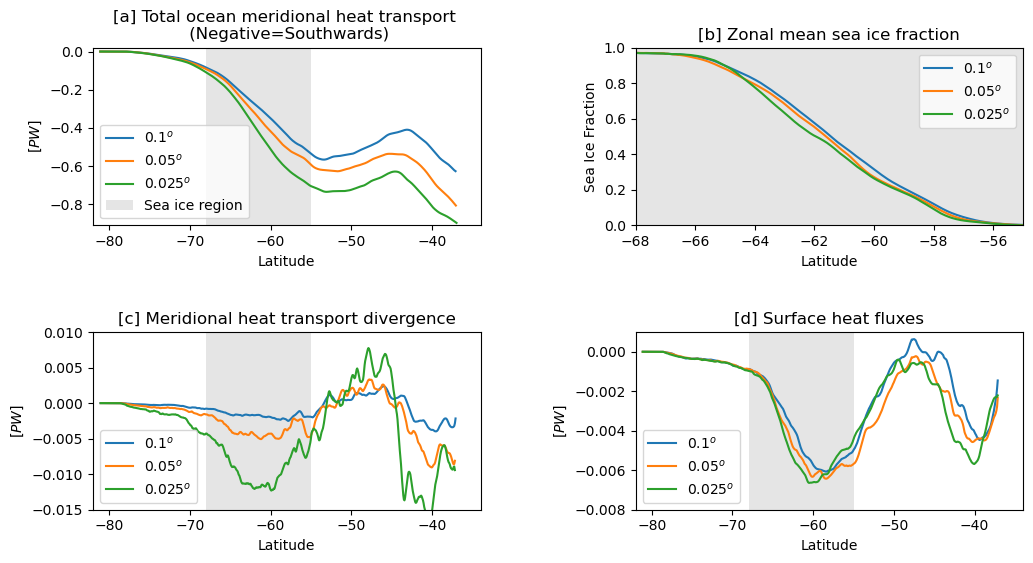

In [39]:
plt.figure(figsize = (12,6))
plt.subplots_adjust(wspace=0.4, hspace=0.6) 

# Add the polygon to the axes
ax = plt.subplot(2,2,1)
vertices = [(-68, -1), (-68, 0.1), (-55, 0.1), (-55, -1),(-68, -1)]
polygon = Polygon(vertices, closed=True, facecolor='grey', edgecolor=None,alpha=0.2,label='Sea ice region')

(1e-15 * MHT01).plot(label=r'$0.1^o$')
(1e-15 * MHT005).plot(label=r'$0.05^o$')
(1e-15 * MHT0025).plot(label=r'$0.025^o$')
# plt.plot([-68,-68],[-1,0.1],color='grey',linewidth=0.5)
# plt.plot([-55,-55],[-1,0.1],color='grey',linewidth=0.5)
ax.add_patch(polygon)
plt.legend()
plt.ylim(-0.91,0.02)
plt.xlim(-82,-34)
plt.ylabel('[$PW$]')
plt.xlabel('Latitude')
plt.title('[a] Total ocean meridional heat transport \n (Negative=Southwards)')

ax2 = plt.subplot(2,2,2)
vertices = [(-68, -1), (-68, 1), (-55, 1), (-55, -1),(-68, -1)]
polygon = Polygon(vertices, closed=True, facecolor='grey', edgecolor=None,alpha=0.2,label='Sea ice region')
SIC01_winter.plot(label=r'$0.1^o$',color='tab:blue')
SIC005_winter.plot(label=r'$0.05^o$',color='tab:orange')
SIC0025_winter.plot(label=r'$0.025^o$',color='tab:green')
plt.legend()
plt.xlim(-68,-55)
plt.ylim(0,1)
ax2.add_patch(polygon)
plt.ylabel('Sea Ice Fraction')
plt.xlabel('Latitude')
plt.title('[b] Zonal mean sea ice fraction')


ax3 = plt.subplot(2,2,3)
vertices = [(-68, -0.015), (-68, 0.010), (-55, 0.010), (-55, -0.015),(-68, -0.015)]
polygon = Polygon(vertices, closed=True, facecolor='grey', edgecolor=None,alpha=0.2,label='Sea ice region')
(1e-15 * MHT01.diff('yq')).plot(label=r'$0.1^o$')
(1e-15 * MHT005_into01.diff('yq')).plot(label=r'$0.05^o$')
(1e-15 * MHT0025_into01.diff('yq')).plot(label=r'$0.025^o$')
plt.legend()
plt.ylim(-0.015,0.01)
plt.xlim(-82,-34)
ax3.add_patch(polygon)
plt.ylabel('[$PW$]')
plt.xlabel('Latitude')
plt.title('[c] Meridional heat transport divergence')




ax4 = plt.subplot(2,2,4)
vertices = [(-68, -0.015), (-68, 0.010), (-55, 0.010), (-55, -0.015),(-68, -0.015)]
polygon = Polygon(vertices, closed=True, facecolor='grey', edgecolor=None,alpha=0.2,label='Sea ice region')
(1e-15 * SHF01_winter_Zsum).plot(label=r'$0.1^o$')
(1e-15 * SHF005_winter_ZM_into01).plot(label=r'$0.05^o$')
(1e-15 * SHF0025_winter_ZM_into01).plot(label=r'$0.025^o$')
plt.legend()
plt.ylim(-0.008,0.001)
plt.xlim(-82,-34)
ax4.add_patch(polygon)
plt.ylabel('[$PW$]')
plt.xlabel('Latitude')
plt.title('[d] Surface heat fluxes')



surface heat fluxes actually show no change - except perhaps by a small poleward migration

#### Budget in sea ice zone

Let's integrate the fluxes withing the sea ice box in the winter ($64^oS$-$58^oS$), to see how things change

In [153]:
north_lat = -58
south_lat = -68

###  MHT  balance   ################################################################
#postive here is heat gain
MHT01_balace = - ( MHT01.cf.sel({'latitude':north_lat},method = 'nearest') - \
MHT01.cf.sel({'latitude':south_lat},method = 'nearest'))*1e-15
MHT005_balace = - ( MHT005.cf.sel({'latitude':north_lat},method = 'nearest') - \
MHT005.cf.sel({'latitude':south_lat},method = 'nearest'))*1e-15
MHT0025_balace = - ( MHT0025.cf.sel({'latitude':north_lat},method = 'nearest') - \
MHT0025.cf.sel({'latitude':south_lat},method = 'nearest'))*1e-15

###  SHF  sum   ################################################################
SHF01_balance = SHF01_winter_Zsum.cf.sel({'latitude':slice(south_lat,north_lat)}).sum()*1e-15
SHF005_balance = SHF005_winter_Zsum.cf.sel({'latitude':slice(south_lat,north_lat)}).sum()*1e-15
SHF0025_balance = SHF0025_winter_Zsum.cf.sel({'latitude':slice(south_lat,north_lat)}).sum()*1e-15

###  SHF  sum  ice free ################################################################
SHF01_balance_icefree = SHF01_winter_Zsum_icefree.cf.sel({'latitude':slice(south_lat,north_lat)}).sum()*1e-15
SHF005_balance_icefree = SHF005_winter_Zsum_icefree.cf.sel({'latitude':slice(south_lat,north_lat)}).sum()*1e-15
SHF0025_balance_icefree = SHF0025_winter_Zsum_icefree.cf.sel({'latitude':slice(south_lat,north_lat)}).sum()*1e-15

###  Surface freshwater fluxes   ################################################################
rho = 1035 # to convert to Sv
SIW01_balance = 1e-6 * SIW01_winter_Zsum.cf.sel({'latitude':slice(south_lat,north_lat)}).sum()/rho #Sv
SIW005_balance = 1e-6 * SIW005_winter_Zsum.cf.sel({'latitude':slice(south_lat,north_lat)}).sum()/rho #Sv
SIW0025_balance = 1e-6 * SIW0025_winter_Zsum.cf.sel({'latitude':slice(south_lat,north_lat)}).sum()/rho #Sv


###  Surface freshwater fluxes  only under sea ice ################################################################
rho = 1035 # to convert to Sv
SIW01_balance_icefree = 1e-6 * SIW01_winter_Zsum_icefree.cf.sel({'latitude':slice(south_lat,north_lat)}).sum()/rho #Sv
SIW005_balance_icefree = 1e-6 * SIW005_winter_Zsum_icefree.cf.sel({'latitude':slice(south_lat,north_lat)}).sum()/rho #Sv
SIW0025_balance_icefree = 1e-6 * SIW0025_winter_Zsum_icefree.cf.sel({'latitude':slice(south_lat,north_lat)}).sum()/rho #Sv

(0.25, 0.27)

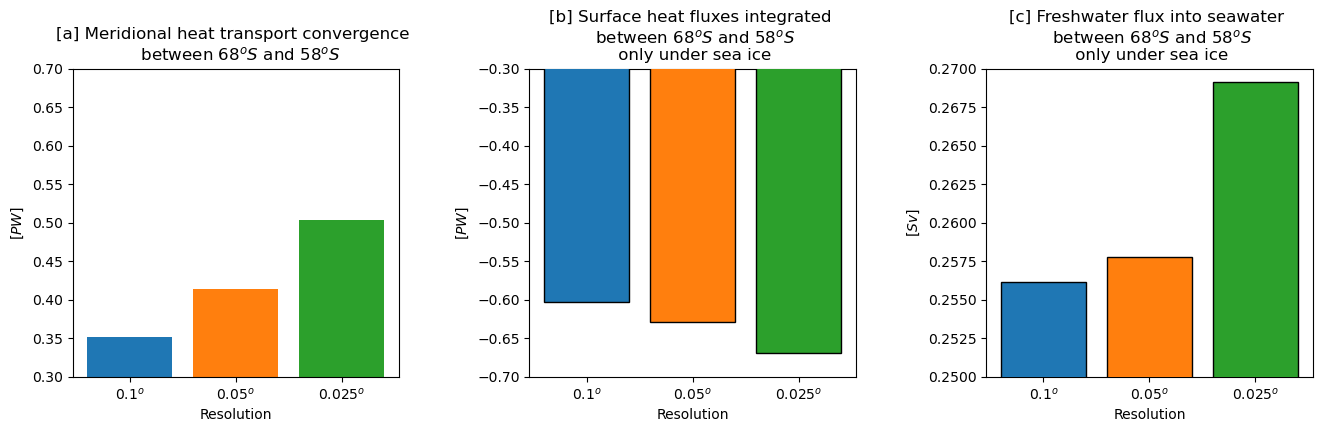

In [159]:
plt.figure(figsize = (16,4))
plt.subplots_adjust(wspace=0.4, hspace=0.6) 


plt.subplot(1,3,1)
plt.bar([0,1,2],[MHT01_balace,MHT005_balace,MHT0025_balace],color=['tab:blue','tab:orange','tab:green'])
plt.title('[a] Meridional heat transport convergence \n ' + r' between $68^oS$ and $58^oS$')
plt.ylabel(r'[$PW$]')
plt.xlabel('Resolution')
plt.xticks([0,1,2],labels=[r'$0.1^o$',r'$0.05^o$',r'$0.025^o$'])
plt.ylim(0.3,0.7)

plt.subplot(1,3,2)
#plt.bar([0,1,2],[SHF01_balance,SHF005_balance,SHF0025_balance],color=['tab:blue','tab:orange','tab:green'])
plt.bar([0,1,2],\
        [SHF01_balance-SHF01_balance_icefree,\
         SHF005_balance-SHF005_balance_icefree,SHF0025_balance-SHF0025_balance_icefree],\
        color=['tab:blue','tab:orange','tab:green'],edgecolor='black',zorder=10)
plt.title('[b] Surface heat fluxes integrated \n ' + r'between $68^oS$ and $58^oS$' + \
          '\n only under sea ice')
plt.ylabel(r'[$PW$]')
plt.xlabel('Resolution')
plt.xticks([0,1,2],labels=[r'$0.1^o$',r'$0.05^o$',r'$0.025^o$'])
plt.ylim(-0.7,-0.3)

plt.subplot(1,3,3)
#plt.bar([0,1,2],[SIW01_balance,SIW005_balance,SIW0025_balance],color=['tab:blue','tab:orange','tab:green'])
plt.bar([0,1,2],[SIW01_balance-SIW01_balance_icefree,\
                 SIW005_balance-SIW005_balance_icefree,\
                 SIW0025_balance-SIW0025_balance_icefree],\
        color=['tab:blue','tab:orange','tab:green'],edgecolor='black',zorder=10)

plt.title('[c] Freshwater flux into seawater \n ' + r'between $68^oS$ and $58^oS$' + \
          '\n only under sea ice')
plt.ylabel(r'[$Sv$]')
plt.xlabel('Resolution')
plt.xticks([0,1,2],labels=[r'$0.1^o$',r'$0.05^o$',r'$0.025^o$'])
plt.ylim(0.25,0.27)

**above are winter fluxes**


ok, as we move to higher resolution, more heat converges in the sea ice region, and more heat is lost to the atmosphere/sea ice in the same region. This tells me that eddies are then brining heat further south to the sea ice region, and this heat then get more easily into the sea ice, melting it (check freswater fluxes into water in c). which likely completes the story


In [260]:
iceheatloss005_round = str(np.round(-(np.round(SHF005_balance-SHF01_balance,2).values-np.round(SHF005_balance_icefree-SHF01_balance_icefree,2).values),2))
iceheatloss005 = -(SHF005_balance-SHF01_balance)+(SHF005_balance_icefree-SHF01_balance_icefree)


print('\n \nThe 1/20th concetrates extra ' + str(np.round(MHT005_balace-MHT01_balace,2).values) +\
      ' PW of heat into the sea ice region and loses extra '+ \
      str(-np.round(SHF005_balance-SHF01_balance,2).values) + \
      ' PW of heat to the atmosphere compared to the 1/10th, ' + \
     'from this ' + str(-np.round(SHF005_balance-SHF01_balance,2).values) + \
      ' PW of heat loss, ' + str(-np.round(SHF005_balance_icefree-SHF01_balance_icefree,2).values) + \
     ' PW is lost in ice free regions and the remaining ' + \
     iceheatloss005_round + ' PW is loss under sea ice. \n \n')




 
The 1/20th concetrates extra 0.06 PW of heat into the sea ice region and loses extra 0.08 PW of heat to the atmosphere compared to the 1/10th, from this 0.08 PW of heat loss, 0.06 PW is lost in ice free regions and the remaining 0.02 PW is loss under sea ice. 
 



In [110]:

iceheatloss0025_round = str(np.round(-(np.round(SHF0025_balance-SHF005_balance,2).values-np.round(SHF0025_balance_icefree-SHF005_balance_icefree,2).values),2))
iceheatloss0025 = -(SHF0025_balance-SHF005_balance)+(SHF0025_balance_icefree-SHF005_balance_icefree)


print('\n \nThe 1/40th concetrates extra ' + str(np.round(MHT0025_balace-MHT005_balace,2).values) +\
      ' PW of heat into the sea ice region and loses extra '+ \
      str(-np.round(SHF0025_balance-SHF005_balance,2).values) + \
      ' PW of heat to the atmosphere compared to the 1/20th, ' + \
     'from this ' + str(-np.round(SHF0025_balance-SHF005_balance,2).values) + \
      ' PW of heat loss, ' + str(-np.round(SHF0025_balance_icefree-SHF005_balance_icefree,2).values) + \
     ' PW is lost in ice free regions and the remaining ' + \
     iceheatloss0025_round + ' PW is loss under sea ice. \n \n')



 
The 1/40th concetrates extra 0.09 PW of heat into the sea ice region and loses extra 0.06 PW of heat to the atmosphere compared to the 1/20th, from this 0.06 PW of heat loss, 0.02 PW is lost in ice free regions and the remaining 0.04 PW is loss under sea ice. 
 



In [461]:
#panan01_TotalHeat = catalog["panant-01-zstar-ACCESSyr2"].search(variable="Heat")
import cftime
from datetime import timedelta
panan01_TotalHeat = xr.open_mfdataset('/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output*/ocean.stats.nc',decode_times=False).Heat.compute()
panan005_TotalHeat = xr.open_mfdataset('/g/data/ol01/outputs/mom6-panan/panant-005-zstar-ACCESSyr2/output*/ocean.stats.nc',decode_times=False).Heat.compute()
panan0025_TotalHeat = xr.open_mfdataset('/g/data/ol01/outputs/mom6-panan/panant-0025-zstar-ACCESSyr2/output*/ocean.stats.nc',decode_times=False).Heat.compute()

In [462]:
#annoying solution to fix time
times01 = xr.apply_ufunc(
    lambda d: cftime.DatetimeNoLeap(1, 1, 1) + timedelta(days=int(d)),
    panan01_TotalHeat.Time,
    vectorize=True,
    dask="parallelized",  # safe for large arrays
    output_dtypes=[object]
)

panan01_TotalHeat['Time'] = times01

#annoying solution to fix time
times005= xr.apply_ufunc(
    lambda d: cftime.DatetimeNoLeap(1, 1, 1) + timedelta(days=int(d)),
    panan005_TotalHeat.Time,
    vectorize=True,
    dask="parallelized",  # safe for large arrays
    output_dtypes=[object]
)
panan005_TotalHeat['Time'] = times005

#annoying solution to fix time
times0025= xr.apply_ufunc(
    lambda d: cftime.DatetimeNoLeap(1, 1, 1) + timedelta(days=int(d)),
    panan0025_TotalHeat.Time,
    vectorize=True,
    dask="parallelized",  # safe for large arrays
    output_dtypes=[object]
)
panan0025_TotalHeat['Time'] = times0025


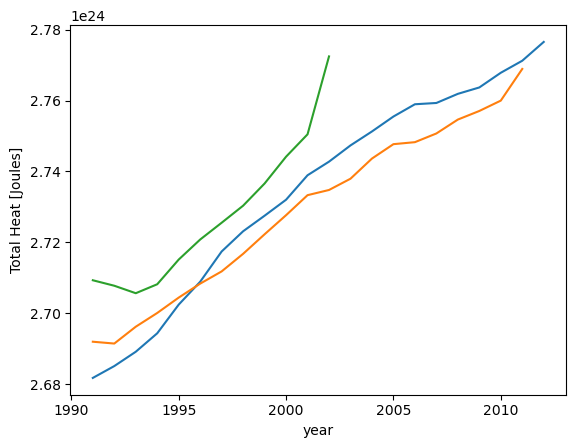

In [466]:
panan01_TotalHeat.groupby('Time.year').mean().plot()
panan005_TotalHeat.groupby('Time.year').mean().plot()
panan0025_TotalHeat.groupby('Time.year').mean().plot()

## Back of envelope melting calculation

Given that we know the difference of heat fluxes under sea ice, we can calcualted if they would be enough to melt the sae ice at the rate we see in the models.

Basically, we know that in MOM6-SIS2 the latent heat flux of freezing/melting is

$L_f = 3.34 \times 10^5 \ [J/kg\ $or$\ (W/s)/kg]$


the density of sea ice in SIS2 is set to:

$\rho_{ice} = 900 \ [kg/m^{3}]$

We can estimate the ammount of heat required to melt $1\ m^{3}$ of sea ice by doing

$Q_{rate} = \rho_{ice}\ L_f \ [J/m^{3} $ or $ W/s/m^{3}]$

so $Q_{rate}$ is basically the rate of heat flux in $W/s$ required to melt a $m^3$ of sea ice


We also have the total difference of heat fluxes between simulations $\Delta Q$ in $W$. Hence, the predicted extra melting rate based on the additional heat flux can be calculated as

$$
    FW_{melt} = \frac{\Delta Q}{(\rho_{ice} \times L_f) }\times 10^{-6} \ \ \ \Biggl[\frac{W}{\frac{kg}{m^3} \times \frac{W/s}{kg}}  \times 10^{-6}= Sv \Biggl] 
$$


Notice, that $FW_{melt}$ would only predict the melting, while the freshwater fluxes outputed by the model are the net between basal melt and surface freezing. So they wont be the same value. But that is no problem, we just want to see if the additional heat flux into theice is enough to melt at least the same ammout of sea ice as diagnosed by the net fluxes outputed by the model


**Bias warning:** This calculation assumes that sea ice is at the freezing temperature. But given that the mean SST under sea ice -s $-1.3 ^oC$, and feezing point at $S = 33\ PSU$ is about $-1.8^oC$, then this shouldn't be a problem

In [232]:
panan01_Temp= catalog["panant-01-zstar-ACCESSyr2"].search(variable="thetao", frequency = '1mon')\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).thetao.sel(time=time_slice).isel(z_l=0).groupby('time.month').mean()
panan01_Temp_winter = panan01_Temp.sel(month = Month_inds).mean('month').compute()
#extracting only sea ice lat range
panan01_Temp_winter = panan01_Temp_winter.cf.sel({'latitude':slice(south_lat,north_lat)})
#filteringonly regions under ice
panan01_Temp_winter = panan01_Temp_winter.where(panant01_SIC.sel(month = Month_inds).mean('month')!=0)
#average temperature under sea ice
panan01_Temp_winter_mean = panan01_Temp_winter.weighted(panant01_fullarea.fillna(0)).mean().compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [245]:
panan01_Salt= catalog["panant-01-zstar-ACCESSyr2"].search(variable="so", frequency = '1mon')\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).so.sel(time=time_slice).isel(z_l=0).groupby('time.month').mean()
panan01_Salt_winter = panan01_Salt.sel(month = Month_inds).mean('month').compute()
#extracting only sea ice lat range
panan01_Salt_winter = panan01_Salt_winter.cf.sel({'latitude':slice(south_lat,north_lat)})
#filteringonly regions under ice
panan01_Salt_winter = panan01_Salt_winter.where(panant01_SIC.sel(month = Month_inds).mean('month')!=0)
#average temperature under sea ice
panan01_Salt_winter_mean = panan01_Salt_winter.weighted(panant01_fullarea.fillna(0)).mean().compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


In [257]:
#calcualte freezing point
from gsw import CT_freezing
CT_freezing(panan01_Salt_winter_mean,panan01_Salt_winter_mean.z_l,1).values

array(-1.85074318)

In [233]:
#extra freshwater fluxes under sea ice in Sv when changing resolution
Extra_FW_underice005 = (SIW005_balance-SIW005_balance_icefree)-(SIW01_balance-SIW01_balance_icefree)
Extra_FW_underice0025 = (SIW0025_balance-SIW0025_balance_icefree)-(SIW005_balance-SIW005_balance_icefree)

In [234]:
#Density of sea ice from MOM6-panan
𝜌SI =900 # kg m−3
# Latent heat of fusion of ice  from MOM6-panan
Lf = 3.34E+05 #J Kg-1
SItemp = panan01_Temp_winter_mean.values # sea ice mean temperature in celsius
TFREEZE_S0_P0 = 0.0 #freezing/melting point of freshwater at surface. we are assuming se aice is fresh
CSI = 2100 # J/Kg/K specific heat of sea ice in the model
# ICE_melt from mom6-SIS2
ICE_KMELT  = 240 #[W m-2 K-1] constant that estiamte sea ice heat fluxes given a deltaT between ice and ocean
#Sea ice area 
continent_mask = (1+panant01_SIC.isel(month=0)*0).fillna(0)
SIarea01 = (((panant01_SIC.sel(month = Month_inds).mean('month')!=0))*panant01_fullarea.fillna(0)*continent_mask)
SIarea01_total = SIarea01.sum().compute() #m2
#sea ice volume in m,3
SIvol01_total = ((panant01_SIT.sel(month = Month_inds).mean('month')!=0)*panant01_fullarea.fillna(0)*continent_mask).sum()



We can calculate the heat fluxes required to raise the ice temperature to 0 celsius with $Q = mc\Delta T$

In [237]:
# the extra heat fluxes into the sea ice in panan005 would cause the following extra melting relative to panan01
FW005_extramelting = (1e15*iceheatloss005)/(𝜌SI*Lf*1e6 )
# the extra heat fluxes into the sea ice in panan0025 would cause the following extra melting relative to panan005
FW0025_extramelting = (1e15*iceheatloss0025)/(𝜌SI*Lf*1e6 )


In [238]:
FW005_extramelting,Extra_FW_underice005

(<xarray.DataArray ()> Size: 8B
 array(0.08788937),
 <xarray.DataArray ()> Size: 8B
 array(0.00161481))

In [239]:
FW0025_extramelting,Extra_FW_underice0025

(<xarray.DataArray ()> Size: 8B
 array(0.1309623),
 <xarray.DataArray ()> Size: 8B
 array(0.01138931))

We know we have more heat fluxes under sea ice in the higher resolutions. However why does that happen?

[H1] - Higher temperature difference from ocean to ATM, as more hrat is transported southwards

[H2] - More eddies, pulling more heat towards the surface through Eddy-Ice-Pumping


### Surface temperature differences

In [511]:
#panan01
panan01_Temp= catalog["panant-01-zstar-ACCESSyr2"].search(variable="thetao", frequency = '1mon')\
    .to_dask(xarray_open_kwargs={'decode_timedelta':True}).thetao.sel(time=time_slice).isel(z_l=0).groupby('time.month').mean()
panan01_Temp_winter_T = panan01_Temp.sel(month = Month_inds).mean('month').compute()
#extracting only sea ice lat range
#filteringonly regions under ice
panan01_Temp_winter_T = panan01_Temp_winter_T.where(panant01_SIC.sel(month = Month_inds).mean('month')!=0)
panan01_Temp_winter_ZM = panan01_Temp_winter_T.weighted(panant01_fullarea.fillna(0)).mean('xh').compute()


#panan005

panant005_fullarea = catalog["panant-005-zstar-ACCESSyr2"].search(variable="areacello").to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello
panan005_Temp= catalog["panant-005-zstar-ACCESSyr2"].search(variable="thetao", file_id='ocean.1mon.nv:2.xh:7200.xq:7201.yh:1690.yq:1691.z_i:76.z_l:75')\
     .to_dask(xarray_open_kwargs={'decode_timedelta':True}).thetao.sel(time=time_slice).isel(z_l=0).groupby('time.month').mean()
panan005_Temp_winter_T = panan005_Temp.sel(month = Month_inds).mean('month').compute()
#extracting only sea ice lat range
#filteringonly regions under ice
panan005_Temp_winter_T = panan005_Temp_winter_T.where(panant005_SIC.sel(month = Month_inds).mean('month')!=0)
panan005_Temp_winter_ZM = panan005_Temp_winter_T.weighted(panant005_fullarea.fillna(0)).mean('xh').compute()


# #panan0025
panant0025_fullarea = catalog["panant-0025-zstar-ACCESSyr2"].search(variable="areacello").to_dask(xarray_open_kwargs={'decode_timedelta':True}).areacello
panan0025_Temp= catalog["panant-0025-zstar-ACCESSyr2"].search(variable="thetao", file_id='ocean.1mon.nv:2.xh:14400.xq:14401.yh:3383.yq:3384.z_i:76.z_l:75')\
      .to_dask(xarray_open_kwargs={'decode_timedelta':True}).thetao.sel(time=time_slice).isel(z_l=0).groupby('time.month').mean()
panan0025_Temp_winter_T = panan0025_Temp.sel(month = Month_inds).mean('month').compute()
#extracting only sea ice lat range
#filteringonly regions under ice
panan0025_Temp_winter_T = panan0025_Temp_winter_T.where(panant0025_SIC.sel(month = Month_inds).mean('month')!=0)
panan0025_Temp_winter_ZM = panan0025_Temp_winter_T.weighted(panant0025_fullarea.fillna(0)).mean('xh').compute()


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/core.py:301: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/source.py:306: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid

(-1.9, -0.4)

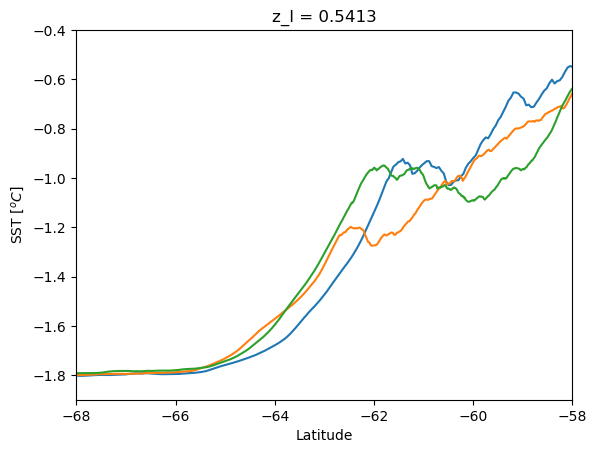

In [523]:
panan01_Temp_winter_ZM.plot()
panan005_Temp_winter_ZM.plot()
panan0025_Temp_winter_ZM.plot()
plt.ylabel(r'SST [$^oC$]')
plt.xlabel('Latitude')
plt.xlim(-68,-58)
plt.ylim(-1.9,-0.4)

It is not super clear to me that the ocean is on average hotter in the higher resolutions (which perhaps could be due to the zonal mean approach - so this needs further evaluation). 

In [524]:
panan0025_Temp_winter_T 

<xarray.DataArray 'thetao' (yh: 2661, xh: 14400)> Size: 153MB
dask.array<where, shape=(2661, 14400), dtype=float32, chunksize=(570, 660), chunktype=numpy.ndarray>
Coordinates:
  * xh       (xh) float64 115kB -280.0 -280.0 -279.9 ... 79.94 79.96 79.99
  * yh       (yh) float64 21kB -81.09 -81.08 -81.07 ... -50.04 -50.02 -50.0
    z_l      float64 8B 0.5413